<a href="https://colab.research.google.com/github/skyexry/data-bootcamp-sp26/blob/main/evaluating_classifier_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Classifier Evaluation

Below, you are asked to build three different classification models using the kidney disease data loaded below.  For further information on the data see [here](https://www.openml.org/search?type=data&status=active&id=42972).

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
kidney = fetch_openml(data_id=42972).frame

In [3]:
kidney.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
kidney.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [5]:
kidney['rc']  = kidney['rc'].replace({"'t?'": np.nan, "'t43'": np.nan}).astype('float')
kidney['pcv'] = kidney['pcv'].replace({"'t?'": np.nan, "'t43'": np.nan}).astype('float')
# kidney['wc'] = kidney['wc'].replace("'t6200'", np.nan).replace("'t8400'").replace("'t?'", np.nan).astype('float')
kidney['wc']  = kidney['wc'].replace({"'t6200'": np.nan, "'t8400'": np.nan, "'t?'": np.nan}).astype('float')

In [6]:
# Clean dirty string artifacts in categorical columns.
#   dm:  'yes', 'no', "' yes'", "'tno'", "'tyes'"     →  'yes', 'no'
#   cad: 'yes', 'no', "'tno'"                         →  'yes', 'no'
#   classification: 'ckd', 'notckd', "'ckdt'"         →  'ckd', 'notckd'

kidney['dm']  = kidney['dm'].replace({"' yes'": 'yes', "'tyes'": 'yes', "'tno'": 'no'})
kidney['cad'] = kidney['cad'].replace({"'tno'": 'no'})
kidney['classification'] = kidney['classification'].replace("'ckdt'", 'ckd')

In [7]:
kidney.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             328 non-null    float64
 17  wc              292 non-null    flo

In [8]:
cat_cols = kidney.select_dtypes('object').columns.tolist()
cat_cols = cat_cols[:-1] # remove 'classification'
print(cat_cols)

['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [9]:
num_cols = kidney.select_dtypes('number').columns.tolist()
num_cols = [c for c in num_cols if c != 'id']  # exclude row ID as it is not a real feature
print(num_cols)

['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']


**Problem 1: Preparing the Data and Basic Modeling**

Below a few steps are completed to prepare the data for a model.  Add comments to each line of code to explain what is happening with the code.

In [10]:
# fills in missing values (NaN) using a specific strategy
from sklearn.impute import SimpleImputer
# applies different transformations to different columns in one step
from sklearn.compose import make_column_transformer

In [11]:
# make all sklearn transformers output pandas DataFrames instead of numpy arrays
from sklearn import set_config
set_config(transform_output="pandas")

In [12]:
# Create a OneHotEncoder that returns a dense array (not sparse matrix)
ohe = OneHotEncoder(sparse_output=False)

# Create an imputer for numeric columns using the column mean to fill missing values
imp_num = SimpleImputer(strategy = 'mean')

# Create an imputer for categorical columns using the most frequent value to fill missing values
imp_cat = SimpleImputer(strategy = 'most_frequent')

# Create a StandardScaler to normalize numeric features to zero mean and unit variance
scale = StandardScaler()

In [13]:
# Build a column transformer that applies numeric imputation to num_cols,
# categorical imputation to cat_cols, and passes remaining columns through unchanged.
# verbose_feature_names_out=False keeps output column names clean (no prefix).
imputer = make_column_transformer((imp_num, num_cols),
                             (imp_cat, cat_cols),
                                verbose_feature_names_out=False,
                             remainder = 'passthrough')

# Rebuild ohe as a column transformer that one-hot encodes cat_cols
# and applies StandardScaler to all remaining (numeric) columns
ohe = make_column_transformer((ohe, cat_cols),
                              remainder = scale)

In [14]:
# chain multiple preprocessing steps and a final estimator into a single object
# so fit/predict/transform run through all steps in order automatically
from sklearn.pipeline import make_pipeline

In [15]:
# Chain the imputer, one-hot encoder, and logistic regression into a single pipeline.
pipe = make_pipeline(imputer, ohe, LogisticRegression())

In [16]:
# Separate features (X) from the target column
# also drop 'id' as it's a row index, not a real feature
X = kidney.drop(columns=['classification', 'id'])
y = kidney['classification']

In [17]:
# Split data: 80% train, 20% test; random_state=12 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 320, Test size: 80


In [18]:
# Fit the full pipeline (imputation + encoding + model) on the training data
pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('simpleimputer-1',
                                                  SimpleImputer(),
                                                  ['age', 'bp', 'sg', 'al',
                                                   'su', 'bgr', 'bu', 'sc',
                                                   'sod', 'pot', 'hemo', 'pcv',
                                                   'wc', 'rc']),
                                                 ('simpleimputer-2',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['rbc', 'pc', 'pcc', 'ba',
                                                   'htn', 'dm', 'cad', 'appet',
                                                   'pe', 'ane'])],
                                   verbose_feature_names_out=False)),
                ('columntransformer-2',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['rbc', 'pc', 'pcc', 'ba',
                                                   'htn', 'dm', 'cad', 'appet',
                                                   'pe', 'ane'])])),
                ('logisticregression', LogisticRegression())])

**PROBLEM 2: Split your data**

Split your data into train and test sets below.  Use a `random_state = 12`.

In [19]:
# Split data: 80% train, 20% test; random_state=12 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 320, Test size: 80


**PROBLEM 3: KNN Model**

Build a pipeline called `knn_pipe` to apply your transformations and build a KNN model on the result.  Use the default `n_neighbors = 5` for your estimator.

In [20]:
# Build a KNN pipeline: impute → encode → KNN with default n_neighbors=5
knn_pipe = make_pipeline(imputer, ohe, KNeighborsClassifier(n_neighbors=5))
knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('simpleimputer-1',
                                                  SimpleImputer(),
                                                  ['age', 'bp', 'sg', 'al',
                                                   'su', 'bgr', 'bu', 'sc',
                                                   'sod', 'pot', 'hemo', 'pcv',
                                                   'wc', 'rc']),
                                                 ('simpleimputer-2',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['rbc', 'pc', 'pcc', 'ba',
                                                   'htn', 'dm', 'cad', 'appet',
                                                   'pe', 'ane'])],
                                   verbose_feature_names_out=False)),
                ('columntransformer-2',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['rbc', 'pc', 'pcc', 'ba',
                                                   'htn', 'dm', 'cad', 'appet',
                                                   'pe', 'ane'])])),
                ('kneighborsclassifier', KNeighborsClassifier())])

**PROBLEM 4: Evaluating the Model**

Visualize the confusion matrix on the train and test data.  Is your model overfit?  What is the recall of the classifier?

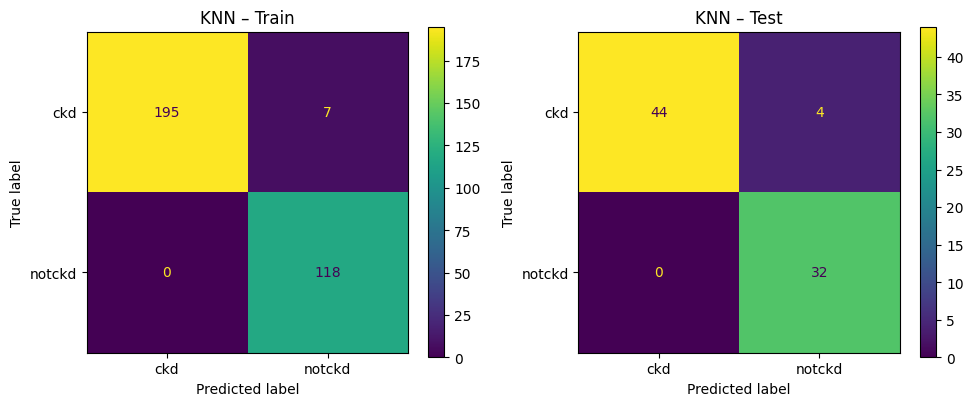

Train Recall (CKD): 0.965
Test  Recall (CKD): 0.917


In [21]:
from sklearn.metrics import recall_score

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix on training data
ConfusionMatrixDisplay.from_estimator(knn_pipe, X_train, y_train, ax=axes[0])
axes[0].set_title("KNN – Train")

# Confusion matrix on test data
ConfusionMatrixDisplay.from_estimator(knn_pipe, X_test, y_test, ax=axes[1])
axes[1].set_title("KNN – Test")
plt.tight_layout()
plt.show()

# Binary recall on the positive (CKD) class — TP / (TP + FN)
train_recall = recall_score(y_train, knn_pipe.predict(X_train), pos_label='ckd')
test_recall  = recall_score(y_test,  knn_pipe.predict(X_test),  pos_label='ckd')
print(f"Train Recall (CKD): {train_recall:.3f}")
print(f"Test  Recall (CKD): {test_recall:.3f}")
# If Train Recall >> Test Recall the model is overfit.

Train recall (0.965) is slightly higher than test recall (0.917), with a gap of about 5 percentage points.

**PROBLEM 5: Grid Searching `n_neighbors`**

Next, set up and fit a grid search on your `knn_pipe` to test the parameters given in `params` below.  Set the `scoring` argument in `GridSearchCV` to recall.  What is the recall on the test data of the best model?  What were the optimal number of neighbors?

In [22]:
params = {'model__n_neighbors': np.arange(1, 30, 2)}
params

{'model__n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29])}

In [23]:
from sklearn.metrics import make_scorer

# Binary recall on positive class (ckd)
recall_scorer = make_scorer(recall_score, pos_label='ckd')
params_knn = {'kneighborsclassifier__n_neighbors': np.arange(1, 30, 2)}

gs_knn = GridSearchCV(knn_pipe, params_knn, scoring=recall_scorer, cv=5, n_jobs=-1)
gs_knn.fit(X_train, y_train)

best_k = gs_knn.best_params_['kneighborsclassifier__n_neighbors']
best_recall = recall_score(y_test, gs_knn.predict(X_test), pos_label='ckd')
print(f"Optimal n_neighbors   : {best_k}")
print(f"Test Recall (best KNN): {best_recall:.3f}")

Optimal n_neighbors   : 1
Test Recall (best KNN): 0.958


**PROBLEM 6: Logistic Model**

Fit a logistic regression pipeline and compare the recall score of the estimator to that of the grid searched knn model.  Which was better?

In [24]:
# Build and fit a logistic regression pipeline using the same preprocessing
lgr_pipe = make_pipeline(imputer, ohe, LogisticRegression(max_iter=1000))
lgr_pipe.fit(X_train, y_train)

# Binary recall on positive class (ckd)
lgr_recall = recall_score(y_test, lgr_pipe.predict(X_test), pos_label='ckd')
print(f"Logistic Regression Test Recall : {lgr_recall:.3f}")
print(f"Best KNN Test Recall            : {best_recall:.3f}")
# The model with the higher recall is better at identifying true CKD cases.

Logistic Regression Test Recall : 0.979
Best KNN Test Recall            : 0.958


Logistic Regression has higher test recall and thus is better at identifying true CKD cases.

**PROBLEM 7: Decision Tree**

Grid search a `DecisionTreeClassifier` using the parameters below, and use recall with the `scoring` argument.  What were the optimal parameters and its recall score on the test data?

In [25]:
params_dt = {'decisiontreeclassifier__max_depth': np.arange(1, 31, 2)}

dt_pipe = make_pipeline(imputer, ohe, DecisionTreeClassifier(random_state=12))

# Binary recall on positive class (ckd)
recall_scorer = make_scorer(recall_score, pos_label='ckd')
gs_dt = GridSearchCV(dt_pipe, params_dt, scoring=recall_scorer, cv=5, n_jobs=-1)
gs_dt.fit(X_train, y_train)

best_depth = gs_dt.best_params_['decisiontreeclassifier__max_depth']
dt_recall  = recall_score(y_test, gs_dt.predict(X_test), pos_label='ckd')
print(f"Optimal max_depth        : {best_depth}")
print(f"Decision Tree Test Recall: {dt_recall:.3f}")

Optimal max_depth        : 3
Decision Tree Test Recall: 1.000


**PROBLEM 8: Lift**

Suppose we only had the opportunity to intervene with the 40% of data we are most confident would have heart disease.  What percentage over our baseline expectations did we capture?  This is referred to as Lift. Compute the lift at 40% for the decision tree model. (Refer [here](https://www2.cs.uregina.ca/~dbd/cs831/notes/lift_chart/lift_chart.html) for more information on lift calculation).



In [26]:
# Compute lift at 40% for the best Decision Tree model
# Lift = (% of positives captured in top p%) / p%  where p = 0.40

pos_label = 'ckd'
print(f"Positive class: '{pos_label}'")

# Get predicted probabilities for the positive class on test set
dt_probs  = gs_dt.predict_proba(X_test)
pos_idx   = list(gs_dt.classes_).index(pos_label)
scores    = dt_probs[:, pos_idx]

# Sort test labels by descending score
sorted_labels = y_test.values[scores.argsort()[::-1]]

n_total  = len(sorted_labels)
n_pos    = (sorted_labels == pos_label).sum()
cutoff   = int(n_total * 0.40)
captured = (sorted_labels[:cutoff] == pos_label).sum()
baseline = 0.40 * n_pos

lift_40percent = (captured / n_pos) / 0.40
print(f"Total instances        : {n_total}")
print(f"Total positives (CKD)  : {n_pos}")
print(f"Positives in top 40%   : {captured}")
print(f"Baseline expected (40%): {baseline:.1f}")

print(f"Lift @ 40%             : {lift_40percent:.3f}")
# Interpretation: a lift of X means the DT captures X times as many
# CKD cases in the top 40% compared to random selection.

Positive class: 'ckd'
Total instances        : 80
Total positives (CKD)  : 48
Positives in top 40%   : 32
Baseline expected (40%): 19.2
Lift @ 40%             : 1.667


**PROBLEM 9: Comparing Lift**

Compute the lift for your logistic and knn models at 40%.  Which model does the best in terms of lift?

In [27]:
def lift_at_p(estimator, X, y, p=0.4, pos_label='ckd'):
    """Cumulative lift at top p fraction of instances ranked by predicted P(positive).
    Lift = (% positives captured in top p) / p."""
    classes  = list(estimator.classes_)
    pos_idx  = classes.index(pos_label)
    scores   = estimator.predict_proba(X)[:, pos_idx]
    labels   = np.asarray(y)[np.argsort(scores)[::-1]]

    n_total  = len(labels)
    n_pos    = (labels == pos_label).sum()
    if n_pos == 0:
        return np.nan                                       # undefined if no positives
    cutoff   = max(1, int(round(n_total * p)))              # guard against cutoff=0
    captured = (labels[:cutoff] == pos_label).sum()
    return (captured / n_pos) / p

lift_lgr = lift_at_p(lgr_pipe, X_test, y_test)
lift_knn = lift_at_p(gs_knn,   X_test, y_test)
lift_dt  = lift_at_p(gs_dt,    X_test, y_test)

print(f"Lift @ 40%  —  Logistic Regression : {lift_lgr:.3f}")
print(f"Lift @ 40%  —  Best KNN            : {lift_knn:.3f}")
print(f"Lift @ 40%  —  Decision Tree       : {lift_dt:.3f}")
print()
best_model = max([('Logistic Regression', lift_lgr),
                  ('Best KNN',            lift_knn),
                  ('Decision Tree',       lift_dt)],
                 key=lambda x: x[1])
print(f"Best model at 40% lift: {best_model[0]} (lift = {best_model[1]:.3f})")

Lift @ 40%  —  Logistic Regression : 1.667
Lift @ 40%  —  Best KNN            : 1.667
Lift @ 40%  —  Decision Tree       : 1.667

Best model at 40% lift: Logistic Regression (lift = 1.667)


**PROBLEM 10: Expected Value**

Read through the chapter from *Data Science for Business* on evaluating classification models.  Pay special attention to the example of the churn data.  Use the cost matrix below to plot the profit curve for the `lgr_pipe` model on the training data (use the kidney data rather than the churn example to demonstrate your understanding).

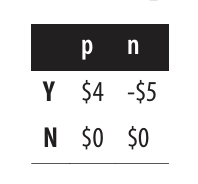

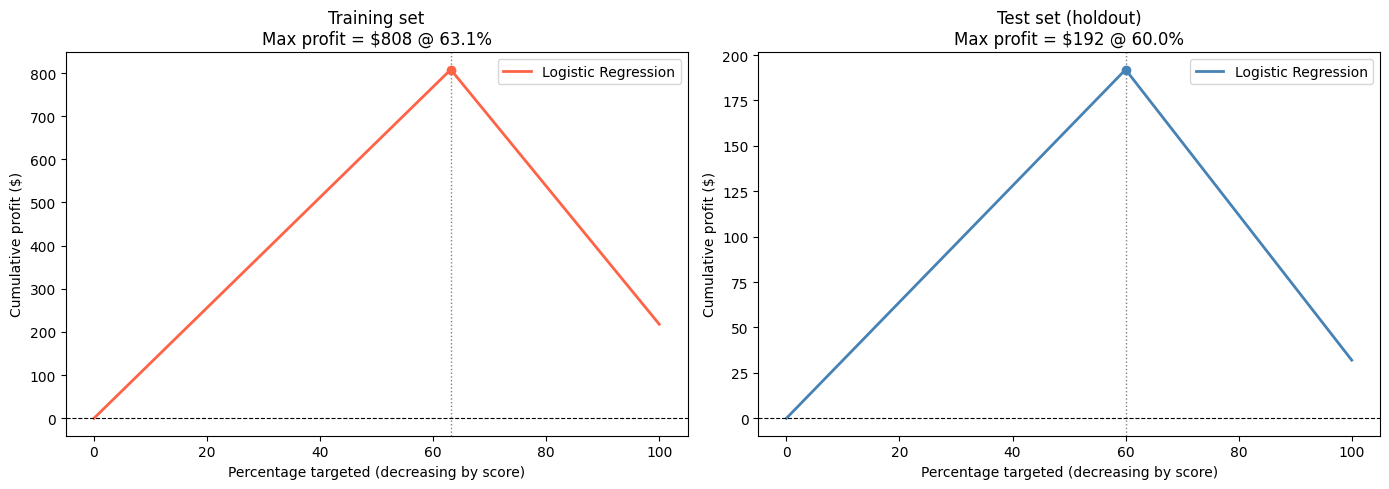

In [29]:
# Plot profit curves on BOTH train and test for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X, y, label, color in [
    (axes[0], X_train, y_train, 'Training set', 'tomato'),
    (axes[1], X_test,  y_test,  'Test set (holdout)', 'steelblue'),
]:
    classes  = list(lgr_pipe.classes_)
    pos_idx  = classes.index('ckd')
    scores   = lgr_pipe.predict_proba(X)[:, pos_idx]
    sorted_y = np.asarray(y)[np.argsort(scores)[::-1]]
    n        = len(sorted_y)

    is_pos = (sorted_y == 'ckd').astype(int)
    profit = np.cumsum(is_pos) * 4 + np.cumsum(1 - is_pos) * (-5)
    profit = np.concatenate(([0], profit))
    pct    = np.concatenate(([0.0], np.arange(1, n+1) / n * 100))

    max_idx = int(np.argmax(profit))
    ax.plot(pct, profit, color=color, lw=2, label='Logistic Regression')
    ax.axhline(0, color='black', linestyle='--', lw=0.8)
    ax.axvline(pct[max_idx], color='gray', linestyle=':', lw=1)
    ax.scatter([pct[max_idx]], [profit[max_idx]], color=color, zorder=5)
    ax.set_xlabel('Percentage targeted (decreasing by score)')
    ax.set_ylabel('Cumulative profit ($)')
    ax.set_title(f'{label}\nMax profit = ${profit[max_idx]} @ {pct[max_idx]:.1f}%')
    ax.legend()

plt.tight_layout()
plt.show()

**BONUS**

While we have many visualization tools in `scikitlearn` -- an updated Lift or Gains curve is still needed.  Write a class `LiftCurveDisplay` that has a `.from_estimator` method that plots a cumulative lift curve given a fit estimator, X, and y.  For an extra bonus repeat for `GainsCurveDisplay` to generate a gains curve.  

If you really really want to go overboard, explore if this is something `scikitlearn` would be interested in incorporating by reading through the contribution guidelines [here](https://scikit-learn.org/stable/developers/contributing.html).

| Method | Role |
|---|---|
| `__init__(...)` | Stores precomputed curve data; no I/O. |
| `.plot(ax=...)` | Draws the figure on a given axes; returns `self` for chaining. |
| `.from_estimator(est, X, y)` | Classmethod: extracts `predict_proba`, computes scores, calls `plot`. |
| `.from_predictions(y_true, y_score)` | Classmethod: works without an estimator (e.g. for ranking models). |

**Definitions used:**
- **Gains** at top fraction $p$ = (positives captured in top $p$) / (total positives). Plotted as percentages on both axes; random baseline is the diagonal $y = x$.
- **Lift** at top fraction $p$ = gains$(p) / p$. Random baseline is the horizontal line $y = 1$.


In [30]:
"""
LiftCurveDisplay and GainsCurveDisplay -- sklearn-style visualization classes
for cumulative lift curves and cumulative gains curves.

  - __init__ stores precomputed curve data
  - .plot() draws the figure and returns self
  - .from_estimator(estimator, X, y) and .from_predictions(y_true, y_score)
    are classmethods that compute the curve and call .plot()
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import check_consistent_length, column_or_1d
from sklearn.utils.validation import check_is_fitted


def _compute_cumulative_curve(y_true, y_score, pos_label):
    """Compute (pct_targeted, gains, lift) arrays for a ranked predictions set.

    Returns
    -------
    pct : ndarray of shape (n_samples + 1,)
        Targeting percentages, including (0, 0) starting point.
    gains : ndarray of shape (n_samples + 1,)
        Cumulative fraction of positives captured. gains[i] in [0, 1].
    lift : ndarray of shape (n_samples + 1,)
        gains / pct (with pct=0 yielding NaN at the start).
    """
    y_true = column_or_1d(y_true)
    y_score = column_or_1d(y_score)
    check_consistent_length(y_true, y_score)

    n_total = len(y_true)
    n_pos = int(np.sum(y_true == pos_label))
    if n_pos == 0:
        raise ValueError(f"No positive samples (pos_label={pos_label!r}) in y_true.")

    # Sort labels by descending score
    order = np.argsort(y_score, kind="mergesort")[::-1]
    sorted_labels = np.asarray(y_true)[order]

    is_pos = (sorted_labels == pos_label).astype(int)
    cum_pos = np.cumsum(is_pos)

    # Prepend the (0, 0) anchor: target nobody -> capture nobody
    pct = np.concatenate(([0.0], np.arange(1, n_total + 1) / n_total))
    gains = np.concatenate(([0.0], cum_pos / n_pos))

    # Lift = gains / pct; first element is 0/0 -> nan
    with np.errstate(divide="ignore", invalid="ignore"):
        lift = np.where(pct > 0, gains / pct, np.nan)

    return pct, gains, lift


class GainsCurveDisplay:
    """Cumulative gains curve visualization.

    Parameters
    ----------
    pct_targeted : ndarray
        Fractions of the population targeted, in [0, 1].
    gains : ndarray
        Fraction of positives captured at each targeting fraction.
    estimator_name : str, default=None
        Name of the estimator (used in the legend).
    pos_label : str or int, default=None
        Label of the positive class (used in axis labels).
    """

    def __init__(self, pct_targeted, gains, *, estimator_name=None, pos_label=None):
        self.pct_targeted = pct_targeted
        self.gains = gains
        self.estimator_name = estimator_name
        self.pos_label = pos_label

    def plot(self, ax=None, name=None, **kwargs):
        """Plot the gains curve. Returns self."""
        if ax is None:
            _, ax = plt.subplots(figsize=(7, 5))

        line_label = name if name is not None else self.estimator_name
        if line_label is None:
            line_label = "Gains curve"

        # Default styling, overridable via kwargs
        plot_kwargs = {"lw": 2}
        plot_kwargs.update(kwargs)

        ax.plot(self.pct_targeted * 100, self.gains * 100,
                label=line_label, **plot_kwargs)
        # Only draw the random baseline once per axes
        if not getattr(ax, "_gains_baseline_drawn", False):
            ax.plot([0, 100], [0, 100], "k--", lw=1, label="Random baseline")
            ax._gains_baseline_drawn = True

        pos_str = f" ({self.pos_label})" if self.pos_label is not None else ""
        ax.set_xlabel("Percentage of samples targeted (sorted by score)")
        ax.set_ylabel(f"Percentage of positives captured{pos_str}")
        ax.set_title("Cumulative Gains Curve")
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 105)
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)

        self.ax_ = ax
        self.figure_ = ax.figure
        return self

    @classmethod
    def from_estimator(cls, estimator, X, y, *, pos_label=None,
                       name=None, ax=None, **kwargs):
        """Compute gains curve from a fitted classifier and plot it."""
        check_is_fitted(estimator)

        if not hasattr(estimator, "predict_proba"):
            raise ValueError(
                f"{type(estimator).__name__} has no predict_proba method. "
                "Use from_predictions with decision_function output instead."
            )

        classes = list(estimator.classes_)
        if pos_label is None:
            pos_label = classes[-1]                   # sklearn convention
        if pos_label not in classes:
            raise ValueError(
                f"pos_label={pos_label!r} not in estimator.classes_={classes}"
            )
        pos_idx = classes.index(pos_label)
        y_score = estimator.predict_proba(X)[:, pos_idx]

        if name is None:
            name = type(estimator).__name__

        return cls.from_predictions(
            y, y_score, pos_label=pos_label, name=name, ax=ax, **kwargs
        )

    @classmethod
    def from_predictions(cls, y_true, y_score, *, pos_label=None,
                         name=None, ax=None, **kwargs):
        """Compute gains curve from ground truth and scores, then plot."""
        if pos_label is None:
            uniq = np.unique(y_true)
            if len(uniq) != 2:
                raise ValueError(
                    "pos_label must be specified for non-binary problems."
                )
            pos_label = uniq[-1]

        pct, gains, _ = _compute_cumulative_curve(y_true, y_score, pos_label)
        viz = cls(pct, gains, estimator_name=name, pos_label=pos_label)
        return viz.plot(ax=ax, name=name, **kwargs)


class LiftCurveDisplay:
    """Cumulative lift curve visualization.

    Parameters
    ----------
    pct_targeted : ndarray
        Fractions of the population targeted, in [0, 1]. Excludes the (0, 0)
        anchor since lift is undefined at p=0.
    lift : ndarray
        Lift values: gains(p) / p at each targeting fraction.
    estimator_name : str, default=None
    pos_label : str or int, default=None
    """

    def __init__(self, pct_targeted, lift, *, estimator_name=None, pos_label=None):
        self.pct_targeted = pct_targeted
        self.lift = lift
        self.estimator_name = estimator_name
        self.pos_label = pos_label

    def plot(self, ax=None, name=None, **kwargs):
        if ax is None:
            _, ax = plt.subplots(figsize=(7, 5))

        line_label = name if name is not None else self.estimator_name
        if line_label is None:
            line_label = "Lift curve"

        plot_kwargs = {"lw": 2}
        plot_kwargs.update(kwargs)

        ax.plot(self.pct_targeted * 100, self.lift,
                label=line_label, **plot_kwargs)
        if not getattr(ax, "_lift_baseline_drawn", False):
            ax.axhline(1.0, color="k", linestyle="--", lw=1, label="Random baseline")
            ax._lift_baseline_drawn = True

        pos_str = f" ({self.pos_label})" if self.pos_label is not None else ""
        ax.set_xlabel("Percentage of samples targeted (sorted by score)")
        ax.set_ylabel(f"Lift{pos_str}")
        ax.set_title("Cumulative Lift Curve")
        ax.set_xlim(0, 100)
        ax.set_ylim(bottom=0)
        ax.legend(loc="upper right")
        ax.grid(alpha=0.3)

        self.ax_ = ax
        self.figure_ = ax.figure
        return self

    @classmethod
    def from_estimator(cls, estimator, X, y, *, pos_label=None,
                       name=None, ax=None, **kwargs):
        check_is_fitted(estimator)

        if not hasattr(estimator, "predict_proba"):
            raise ValueError(
                f"{type(estimator).__name__} has no predict_proba method."
            )

        classes = list(estimator.classes_)
        if pos_label is None:
            pos_label = classes[-1]
        if pos_label not in classes:
            raise ValueError(
                f"pos_label={pos_label!r} not in estimator.classes_={classes}"
            )
        pos_idx = classes.index(pos_label)
        y_score = estimator.predict_proba(X)[:, pos_idx]

        if name is None:
            name = type(estimator).__name__

        return cls.from_predictions(
            y, y_score, pos_label=pos_label, name=name, ax=ax, **kwargs
        )

    @classmethod
    def from_predictions(cls, y_true, y_score, *, pos_label=None,
                         name=None, ax=None, **kwargs):
        if pos_label is None:
            uniq = np.unique(y_true)
            if len(uniq) != 2:
                raise ValueError(
                    "pos_label must be specified for non-binary problems."
                )
            pos_label = uniq[-1]

        pct, _, lift = _compute_cumulative_curve(y_true, y_score, pos_label)
        # Skip the first point (p=0, lift=NaN) for plotting
        viz = cls(pct[1:], lift[1:], estimator_name=name, pos_label=pos_label)
        return viz.plot(ax=ax, name=name, **kwargs)


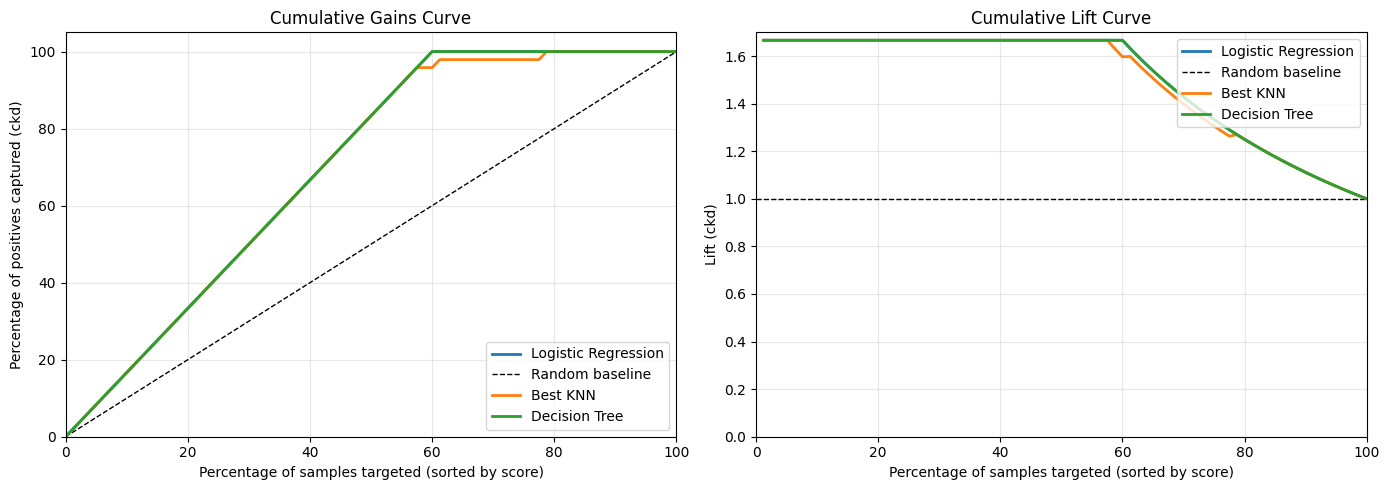

In [31]:
# Demo: compare the three fitted models on a single axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative gains
GainsCurveDisplay.from_estimator(lgr_pipe, X_test, y_test, ax=axes[0],
                                  pos_label='ckd', name='Logistic Regression')
GainsCurveDisplay.from_estimator(gs_knn,   X_test, y_test, ax=axes[0],
                                  pos_label='ckd', name='Best KNN')
GainsCurveDisplay.from_estimator(gs_dt,    X_test, y_test, ax=axes[0],
                                  pos_label='ckd', name='Decision Tree')

# Cumulative lift
LiftCurveDisplay.from_estimator(lgr_pipe, X_test, y_test, ax=axes[1],
                                 pos_label='ckd', name='Logistic Regression')
LiftCurveDisplay.from_estimator(gs_knn,   X_test, y_test, ax=axes[1],
                                 pos_label='ckd', name='Best KNN')
LiftCurveDisplay.from_estimator(gs_dt,    X_test, y_test, ax=axes[1],
                                 pos_label='ckd', name='Decision Tree')

plt.tight_layout()
plt.show()